## PAX Count V2 Analysis — EDA Notebook
**Dataset:** PAX_COUNT_V2.csv | **Rows:** 50,000 | **Columns:** 15

##### 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})

##### 2. Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\hoongliangwong\Downloads\PAX_COUNT_V2.csv")
print(f'Shape: {df.shape}')
df.head()

Shape: (50000, 15)


,IL_DepartureDate,IL_ArrivalDate,Day_of_Week_Departure,Day_of_Week_Arrival,LegNumber,IL_DepartureStation,IL_ArrivalStation,InternationalDesc,LiftStatus,FlyThru,IsNTL,TotalDep,TotalArr,DepartureCountry,ArrivalCountry
0,01-14-25,01-14-25,2,2,A0495,LHR,KUL,INT,Boarded,No,No,224,224,Thailand,Malaysia
1,10-20-25,10-20-25,1,1,A0318,HND,BKK,INT,Default,No,No,69,69,Japan,Thailand
2,10-09-25,10-09-25,4,4,A0499,PEN,LHR,INT,CheckedIn,Yes,No,162,162,Malaysia,Thailand
3,03-06-26,03-06-26,5,5,A0456,PEN,LHR,INT,CheckedIn,Yes,No,132,132,Malaysia,Thailand
4,07-16-25,07-16-25,3,3,A0010,BKI,BKK,INT,CheckedIn,No,No,211,211,Malaysia,Thailand


##### 3. Check for Missing Data

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
})

print('--- Missing Data Report ---')
print(missing_report.to_string())
print()

total_missing = missing.sum()
print(f'Total missing values across all columns: {total_missing}')
if total_missing == 0:
    print('✅ No missing data found across all 15 columns. Proceeding to preprocessing.')
else:
    print(f'⚠️  Total missing values: {total_missing}')

--- Missing Data Report ---
                       Missing Count  Missing (%)
IL_DepartureDate                   0          0.0
IL_ArrivalDate                     0          0.0
Day_of_Week_Departure              0          0.0
Day_of_Week_Arrival                0          0.0
LegNumber                          0          0.0
IL_DepartureStation                0          0.0
IL_ArrivalStation                  0          0.0
InternationalDesc                  0          0.0
LiftStatus                         0          0.0
FlyThru                            0          0.0
IsNTL                              0          0.0
TotalDep                           0          0.0
TotalArr                           0          0.0
DepartureCountry                   0          0.0
ArrivalCountry                     0          0.0

Total missing values across all columns: 0
✅ No missing data found across all 15 columns. Proceeding to preprocessing.


##### 4. Preprocessing

##### 4a. LiftStatus — Already Labelled in V2
> In V2, `LiftStatus` is already stored as descriptive strings (`Default`, `CheckedIn`, `Boarded`, `NoShow`). No numeric mapping is required. We simply confirm the categories present.

In [9]:
# V2: LiftStatus is already a string label — no mapping needed
# Category order defined for consistent chart ordering
LIFT_ORDER = ['Default', 'CheckedIn', 'Boarded', 'NoShow']

print('LiftStatus categories in V2:')
print(df['LiftStatus'].value_counts()[LIFT_ORDER].to_string())
print()
print('✅ LiftStatus confirmed — using column directly as label.')

LiftStatus categories in V2:
LiftStatus
Default      12509
CheckedIn    12591
Boarded      12554
NoShow       12346

✅ LiftStatus confirmed — using column directly as label.


##### 4b. Parse Dates — Extract Month & Year (US Format: MM-DD-YY)

In [5]:
# Dates are in US format: MM-DD-YY
df['DepDate'] = pd.to_datetime(df['IL_DepartureDate'], format='%m-%d-%y')
df['ArrDate'] = pd.to_datetime(df['IL_ArrivalDate'],   format='%m-%d-%y')

df['DepMonth'] = df['DepDate'].dt.month
df['DepYear']  = df['DepDate'].dt.year
df['ArrMonth'] = df['ArrDate'].dt.month
df['ArrYear']  = df['ArrDate'].dt.year

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

df['DepMonthName'] = df['DepMonth'].apply(lambda m: MONTH_NAMES[m-1])
df['ArrMonthName'] = df['ArrMonth'].apply(lambda m: MONTH_NAMES[m-1])

print('Date parsing complete.')
print(f"Departure year range : {df['DepYear'].min()} – {df['DepYear'].max()}")
print(f"Arrival year range   : {df['ArrYear'].min()} – {df['ArrYear'].max()}")
df[['IL_DepartureDate','DepDate','DepMonth','DepYear','DepMonthName']].head()

Date parsing complete.
Departure year range : 2025 – 2026
Arrival year range   : 2025 – 2026


,IL_DepartureDate,DepDate,DepMonth,DepYear,DepMonthName
0,01-14-25,2025-01-14,1,2025,Jan
1,10-20-25,2025-10-20,10,2025,Oct
2,10-09-25,2025-10-09,10,2025,Oct
3,03-06-26,2026-03-06,3,2026,Mar
4,07-16-25,2025-07-16,7,2025,Jul


##### 5. EDA

##### 5a. Monthly Departure Passenger Analysis by Year — One Plot Per Year

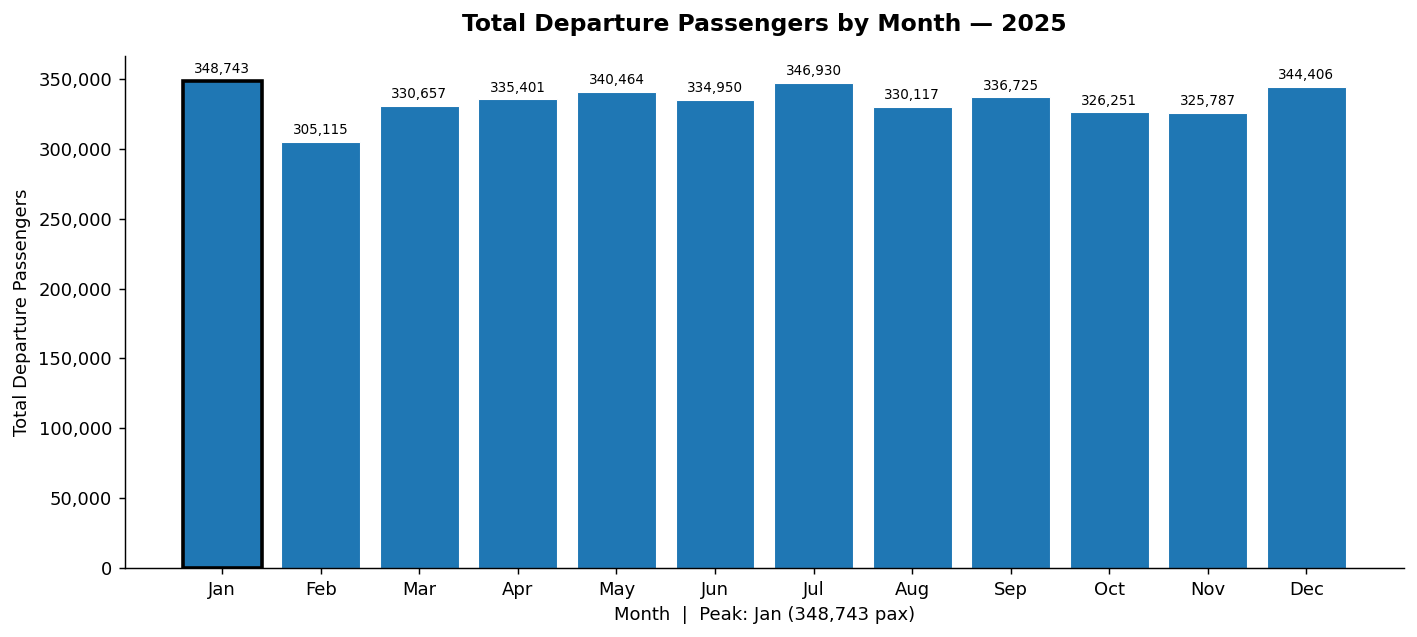

Year 2025 — Peak month: Jan (348,743 pax)



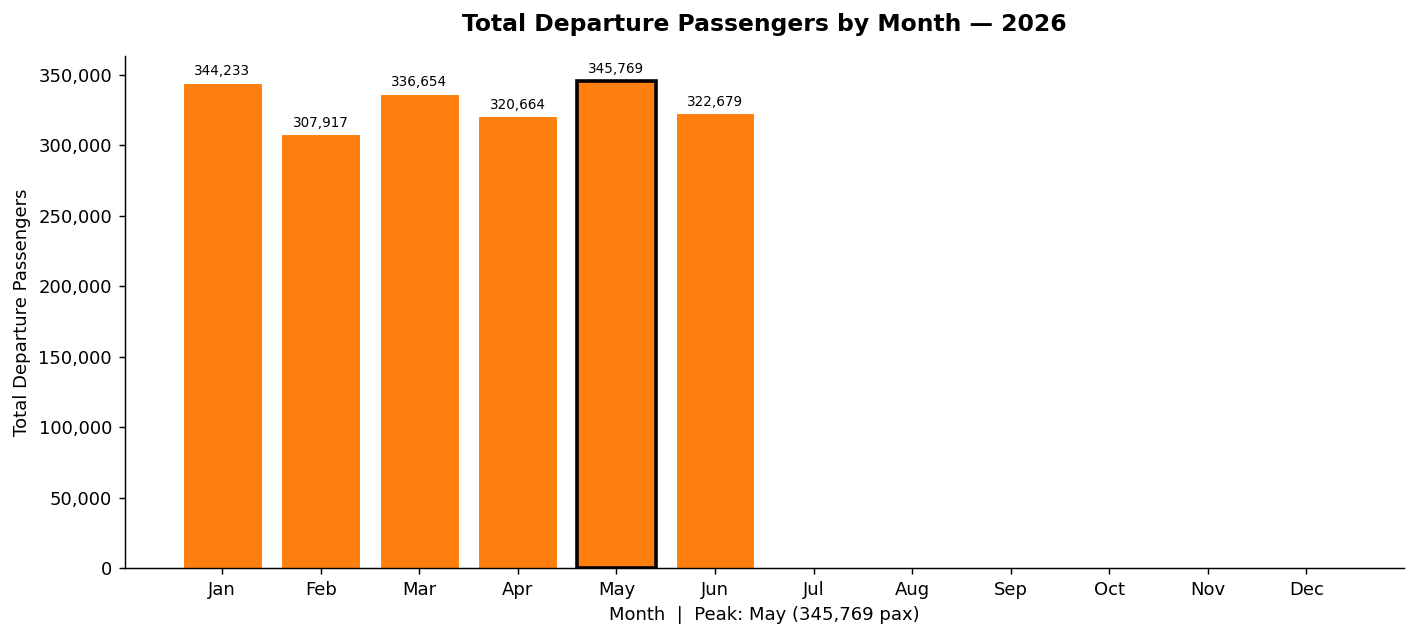

Year 2026 — Peak month: May (345,769 pax)



In [6]:
# V2 uses TotalDep instead of TotalDepPax
dep_years = sorted(df['DepYear'].unique())
COLORS_DEP = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for year, color in zip(dep_years, COLORS_DEP):
    sub = df[df['DepYear'] == year].copy()
    monthly = sub.groupby('DepMonth')['TotalDep'].sum().reindex(range(1, 13), fill_value=0)
    monthly.index = MONTH_NAMES

    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(monthly.index, monthly.values, color=color, edgecolor='white', linewidth=0.6)

    peak_idx = monthly.values.argmax()
    bars[peak_idx].set_edgecolor('black')
    bars[peak_idx].set_linewidth(2)

    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h * 1.01,
                    f'{int(h):,}', ha='center', va='bottom', fontsize=7.5)

    peak_month = monthly.idxmax()
    ax.set_title(f'Total Departure Passengers by Month — {year}', fontsize=13, fontweight='bold', pad=14)
    ax.set_xlabel(f'Month  |  Peak: {peak_month} ({int(monthly.max()):,} pax)')
    ax.set_ylabel('Total Departure Passengers')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.tight_layout()
    plt.show()
    print(f'Year {year} — Peak month: {peak_month} ({int(monthly.max()):,} pax)\n')

##### 5a (cont). Monthly Arrival Passenger Analysis by Year — One Plot Per Year

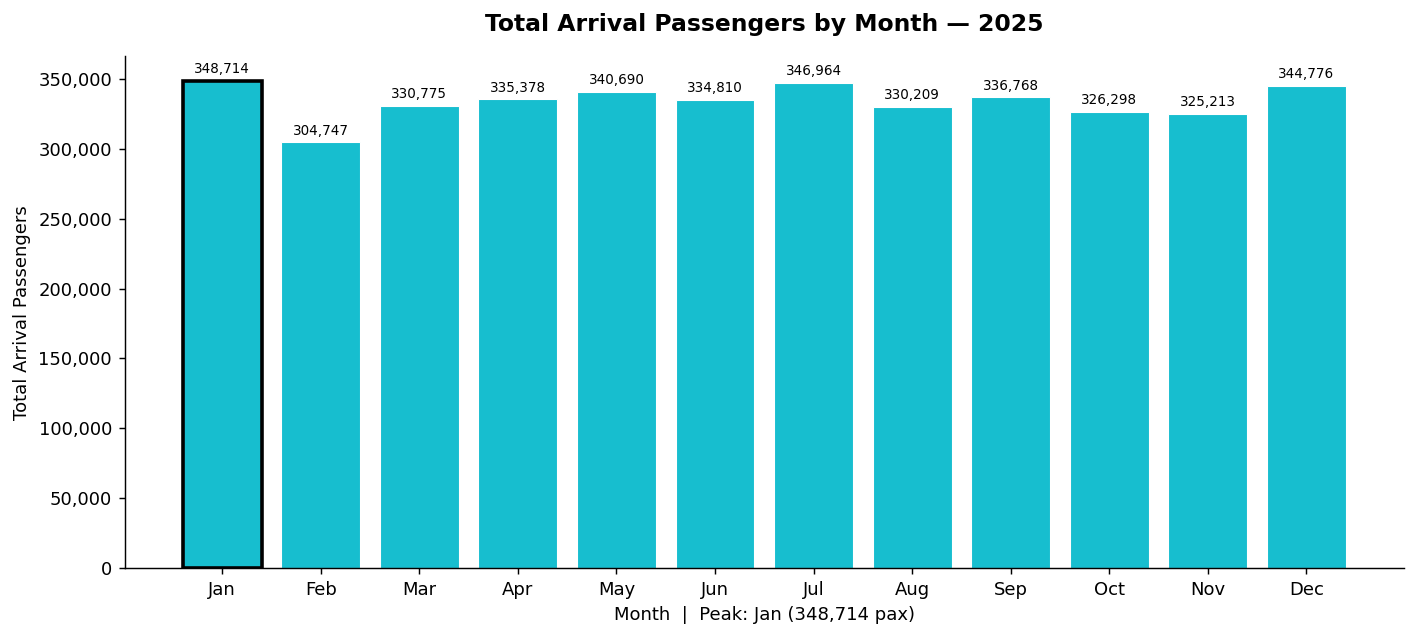

Year 2025 — Peak month: Jan (348,714 pax)



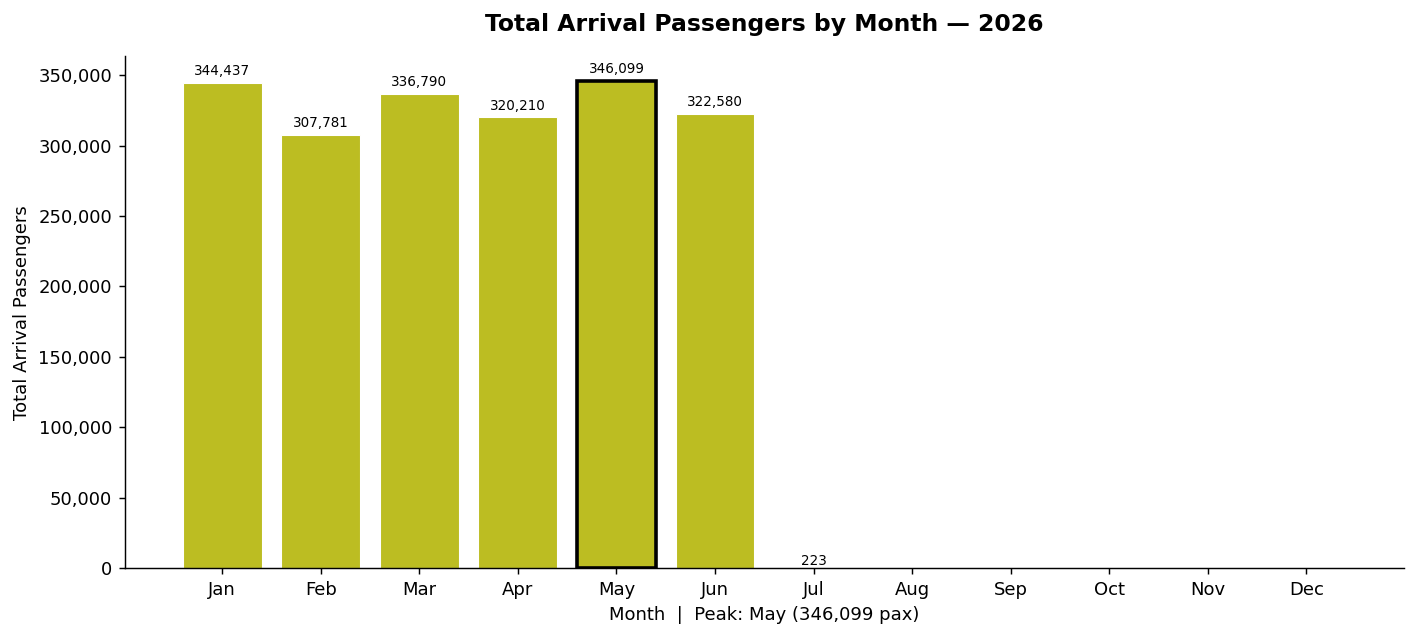

Year 2026 — Peak month: May (346,099 pax)



In [7]:
# V2 uses TotalArr instead of TotalArrPax
arr_years = sorted(df['ArrYear'].unique())
COLORS_ARR = ['#17becf', '#bcbd22', '#e377c2', '#8c564b', '#7f7f7f']

for year, color in zip(arr_years, COLORS_ARR):
    sub = df[df['ArrYear'] == year].copy()
    monthly = sub.groupby('ArrMonth')['TotalArr'].sum().reindex(range(1, 13), fill_value=0)
    monthly.index = MONTH_NAMES

    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(monthly.index, monthly.values, color=color, edgecolor='white', linewidth=0.6)

    peak_idx = monthly.values.argmax()
    bars[peak_idx].set_edgecolor('black')
    bars[peak_idx].set_linewidth(2)

    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h * 1.01,
                    f'{int(h):,}', ha='center', va='bottom', fontsize=7.5)

    peak_month = monthly.idxmax()
    ax.set_title(f'Total Arrival Passengers by Month — {year}', fontsize=13, fontweight='bold', pad=14)
    ax.set_xlabel(f'Month  |  Peak: {peak_month} ({int(monthly.max()):,} pax)')
    ax.set_ylabel('Total Arrival Passengers')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.tight_layout()
    plt.show()
    print(f'Year {year} — Peak month: {peak_month} ({int(monthly.max()):,} pax)\n')

##### 5b. LiftStatus Distribution — Pie Chart (Separate Plot)

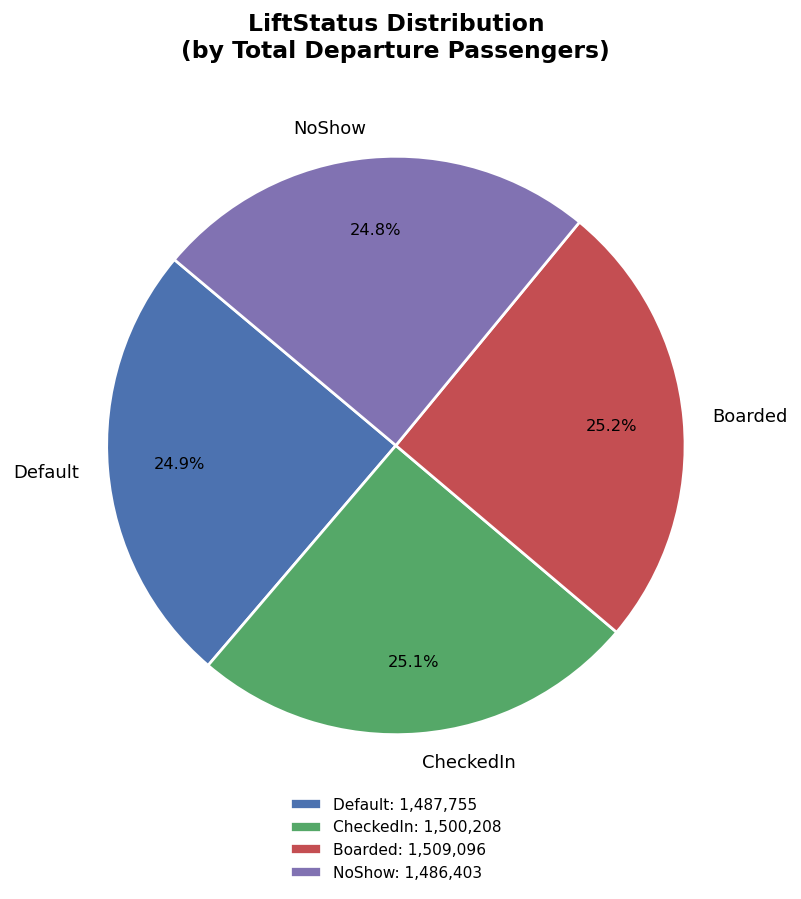

In [10]:
# V2: LiftStatus is already a string — group directly without mapping
# V2: weight by TotalDep
lift_pax = df.groupby('LiftStatus')['TotalDep'].sum().reindex(LIFT_ORDER)
LIFT_COLORS = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    lift_pax.values,
    labels=lift_pax.index,
    autopct='%1.1f%%',
    colors=LIFT_COLORS,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)

legend_labels = [f"{k}: {int(v):,}" for k, v in lift_pax.items()]
ax.legend(wedges, legend_labels, loc='lower center',
          bbox_to_anchor=(0.5, -0.12), fontsize=8.5, frameon=False)
ax.set_title('LiftStatus Distribution\n(by Total Departure Passengers)', pad=15)

plt.tight_layout()
plt.show()

##### 5b (cont). FlyThru Distribution — Pie Chart (Separate Plot)

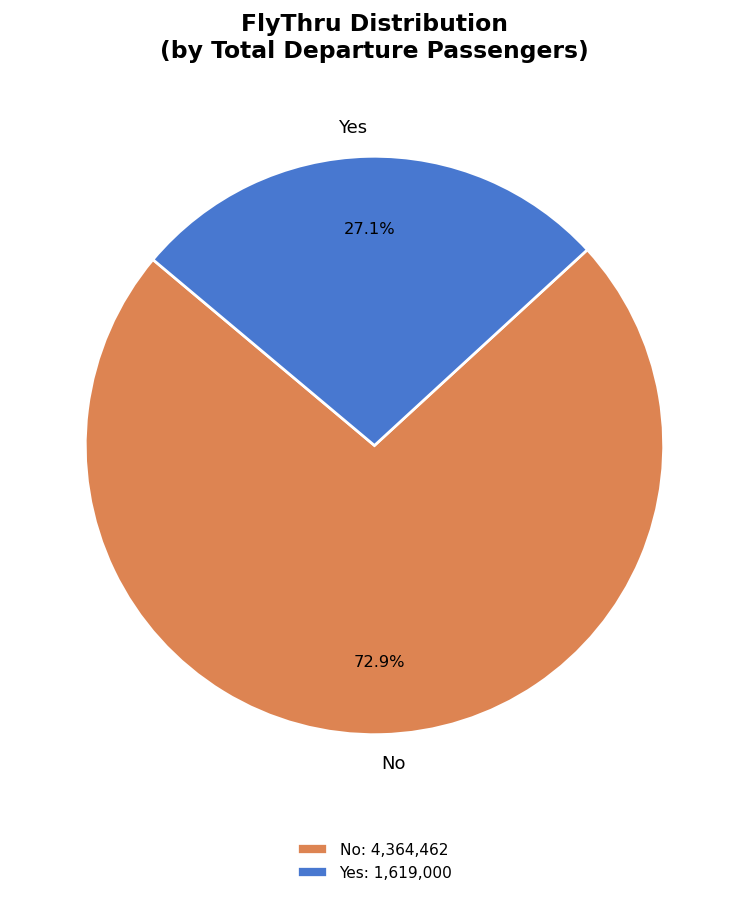

In [11]:
flythru_pax = df.groupby('FlyThru')['TotalDep'].sum()
FT_COLORS = ['#DD8452', '#4878D0']

fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    flythru_pax.values,
    labels=flythru_pax.index,
    autopct='%1.1f%%',
    colors=FT_COLORS,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)

legend_labels = [f"{k}: {int(v):,}" for k, v in flythru_pax.items()]
ax.legend(wedges, legend_labels, loc='lower center',
          bbox_to_anchor=(0.5, -0.12), fontsize=8.5, frameon=False)
ax.set_title('FlyThru Distribution\n(by Total Departure Passengers)', pad=15)

plt.tight_layout()
plt.show()

##### 5b (cont). IsNTL Distribution — Pie Chart (Separate Plot)

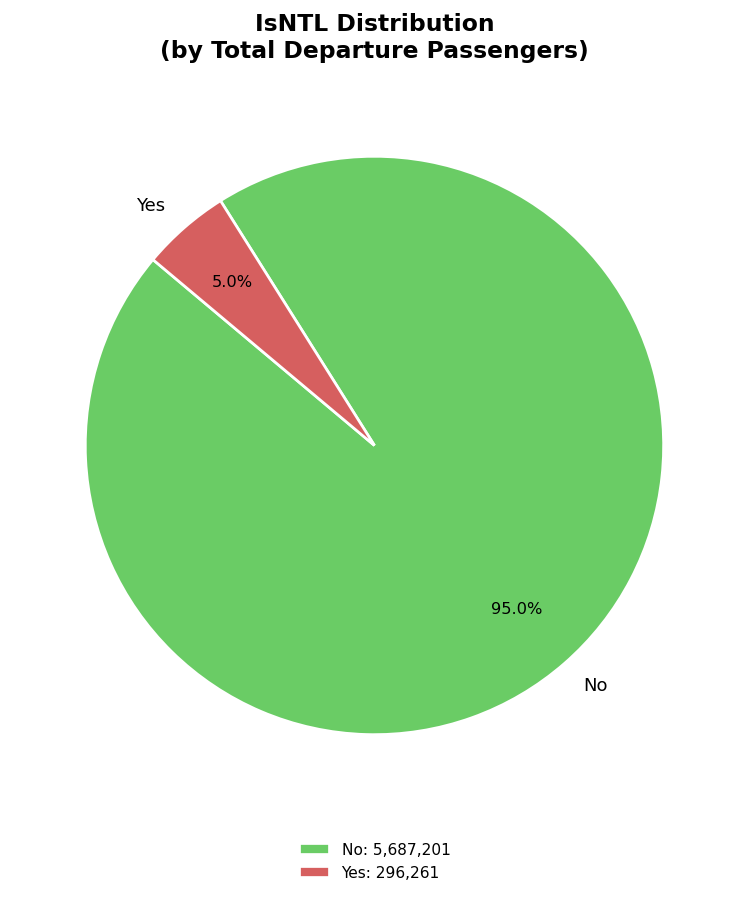

In [12]:
isntl_pax = df.groupby('IsNTL')['TotalDep'].sum()
NTL_COLORS = ['#6ACC65', '#D65F5F']

fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    isntl_pax.values,
    labels=isntl_pax.index,
    autopct='%1.1f%%',
    colors=NTL_COLORS,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)

legend_labels = [f"{k}: {int(v):,}" for k, v in isntl_pax.items()]
ax.legend(wedges, legend_labels, loc='lower center',
          bbox_to_anchor=(0.5, -0.12), fontsize=8.5, frameon=False)
ax.set_title('IsNTL Distribution\n(by Total Departure Passengers)', pad=15)

plt.tight_layout()
plt.show()

##### 5c. Top 10 LegNumber by Total Departure Passengers (Horizontal Bar Chart)

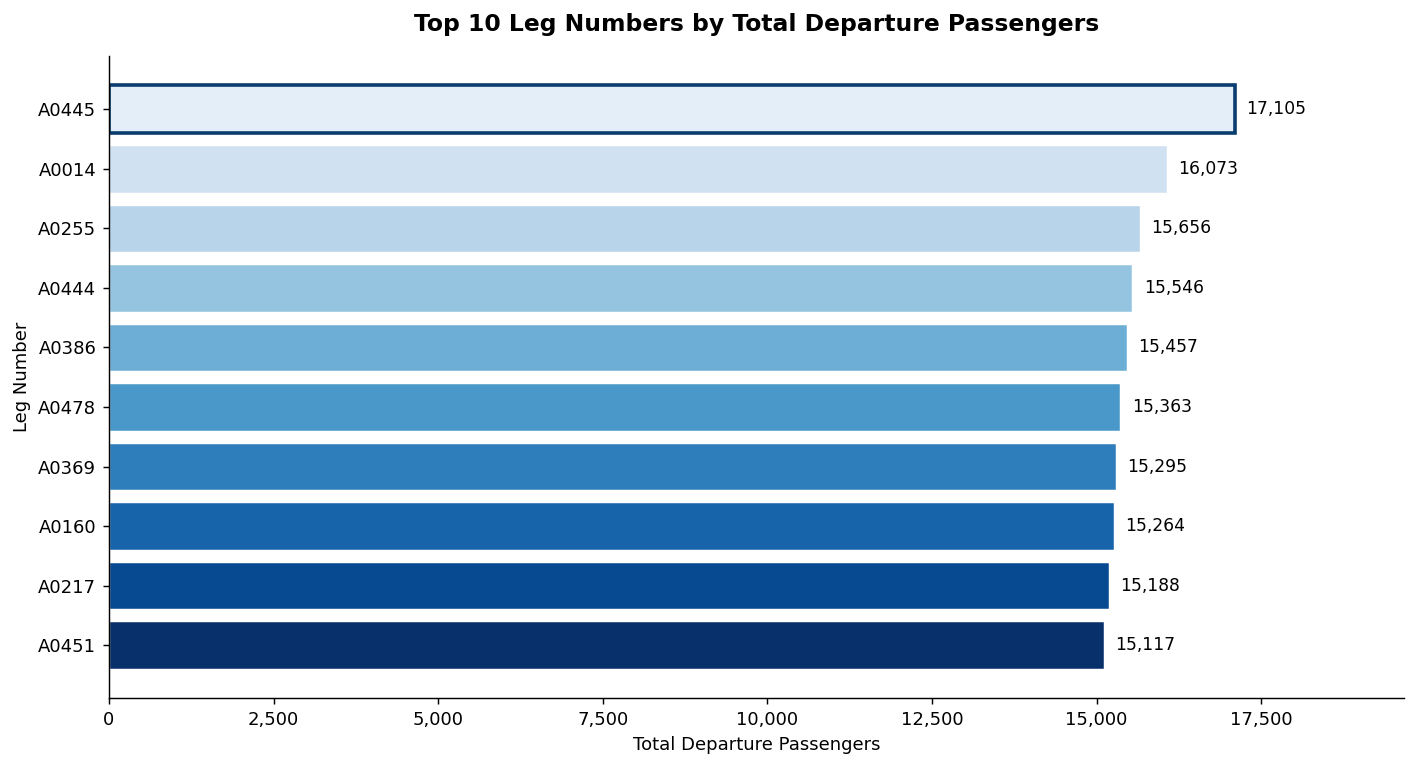

In [13]:
# V2: use TotalDep
top10_leg = (
    df.groupby('LegNumber')['TotalDep']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)   # ascending so highest bar sits at top
)

fig, ax = plt.subplots(figsize=(11, 6))

colors = plt.cm.Blues_r([i / len(top10_leg) for i in range(len(top10_leg))])
bars = ax.barh(top10_leg.index.astype(str), top10_leg.values,
               color=colors, edgecolor='white', linewidth=0.8)

# Highlight the top bar
bars[-1].set_edgecolor('#0a3d6e')
bars[-1].set_linewidth(2)

for bar in bars:
    w = bar.get_width()
    ax.text(w + top10_leg.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{int(w):,}', va='center', fontsize=9.5)

ax.set_title('Top 10 Leg Numbers by Total Departure Passengers', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Total Departure Passengers')
ax.set_ylabel('Leg Number')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, top10_leg.max() * 1.15)

plt.tight_layout()
plt.show()

##### 5d. InternationalDesc Distribution (Pie Chart)

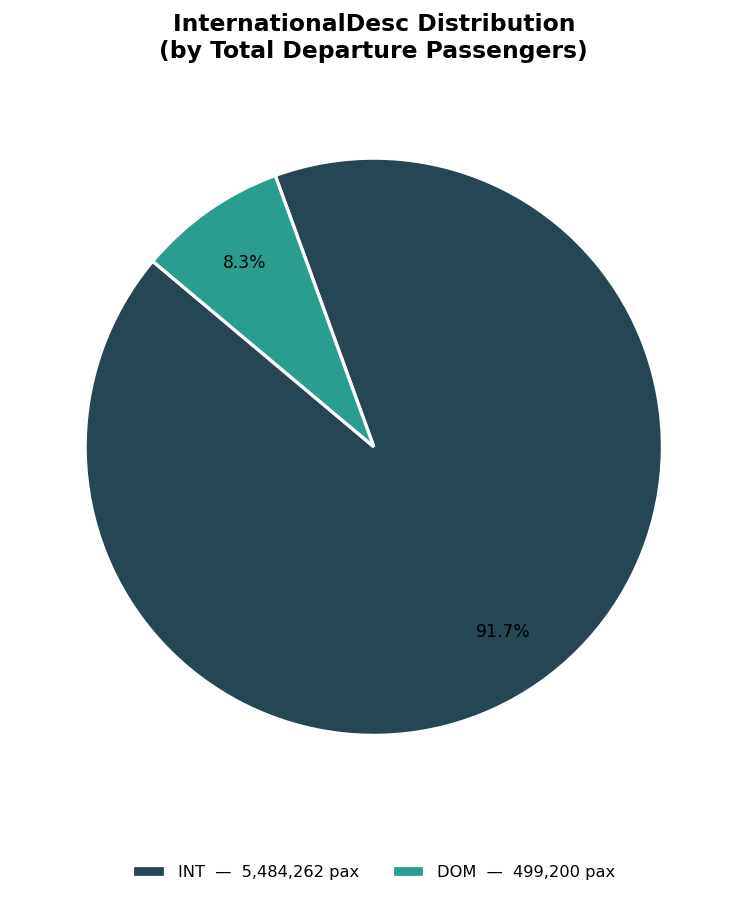

In [14]:
# V2: use TotalDep
intl_pax = df.groupby('InternationalDesc')['TotalDep'].sum().sort_values(ascending=False)

INTL_COLORS = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51',
               '#457B9D', '#A8DADC', '#F1FAEE', '#E63946', '#6A4C93']

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    intl_pax.values,
    labels=None,
    autopct='%1.1f%%',
    colors=INTL_COLORS[:len(intl_pax)],
    startangle=140,
    pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.8}
)
for at in autotexts:
    at.set_fontsize(9.5)

legend_labels = [f'{k}  —  {int(v):,} pax' for k, v in intl_pax.items()]
ax.legend(wedges, legend_labels,
          loc='lower center', bbox_to_anchor=(0.5, -0.12),
          fontsize=9, frameon=False, ncol=2)
ax.set_title('InternationalDesc Distribution\n(by Total Departure Passengers)',
             fontsize=13, fontweight='bold', pad=16)

plt.tight_layout()
plt.show()

##### 5e. Top 5 Departure Countries by Total Departure Passengers (Horizontal Bar Chart)

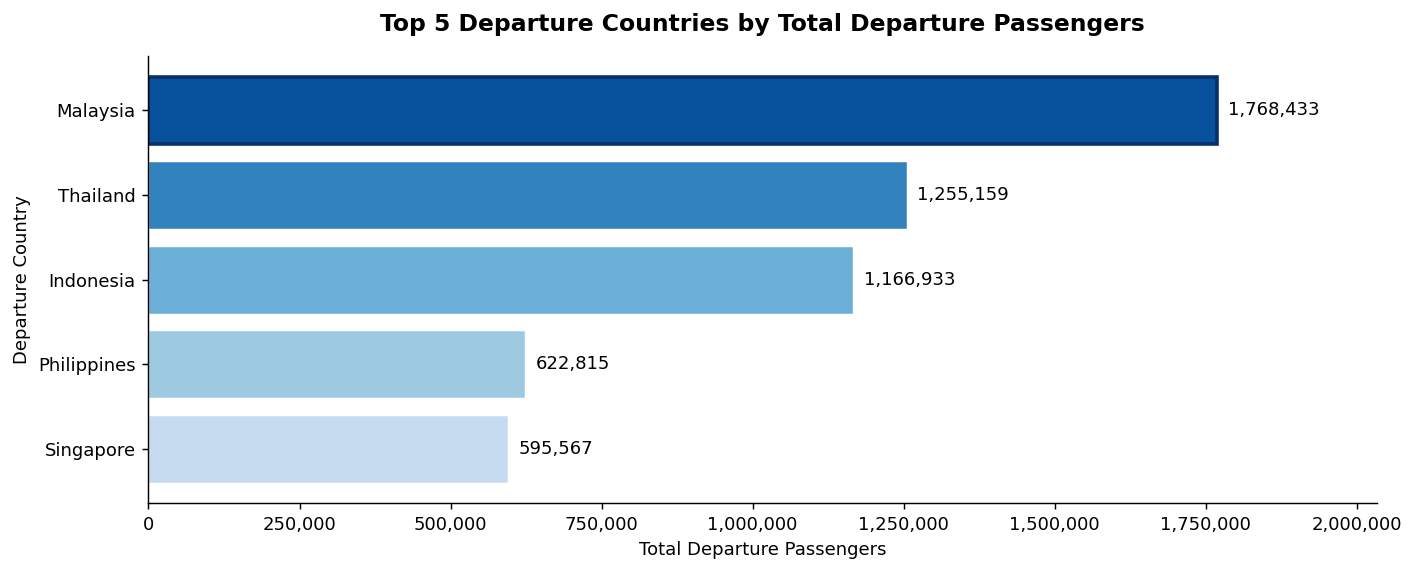

In [15]:
# V2: use TotalDep
top5_dep_country = (
    df.groupby('DepartureCountry')['TotalDep']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 4.5))

dep_colors = ['#c6dbef', '#9ecae1', '#6baed6', '#3182bd', '#08519c']
bars = ax.barh(top5_dep_country.index, top5_dep_country.values,
               color=dep_colors, edgecolor='white', linewidth=0.8)

bars[-1].set_edgecolor('#08306b')
bars[-1].set_linewidth(2)

for bar in bars:
    w = bar.get_width()
    ax.text(w + top5_dep_country.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{int(w):,}', va='center', fontsize=10)

ax.set_title('Top 5 Departure Countries by Total Departure Passengers',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Total Departure Passengers')
ax.set_ylabel('Departure Country')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, top5_dep_country.max() * 1.15)

plt.tight_layout()
plt.show()

##### 5f. Top 5 Arrival Countries by Total Arrival Passengers (Horizontal Bar Chart)

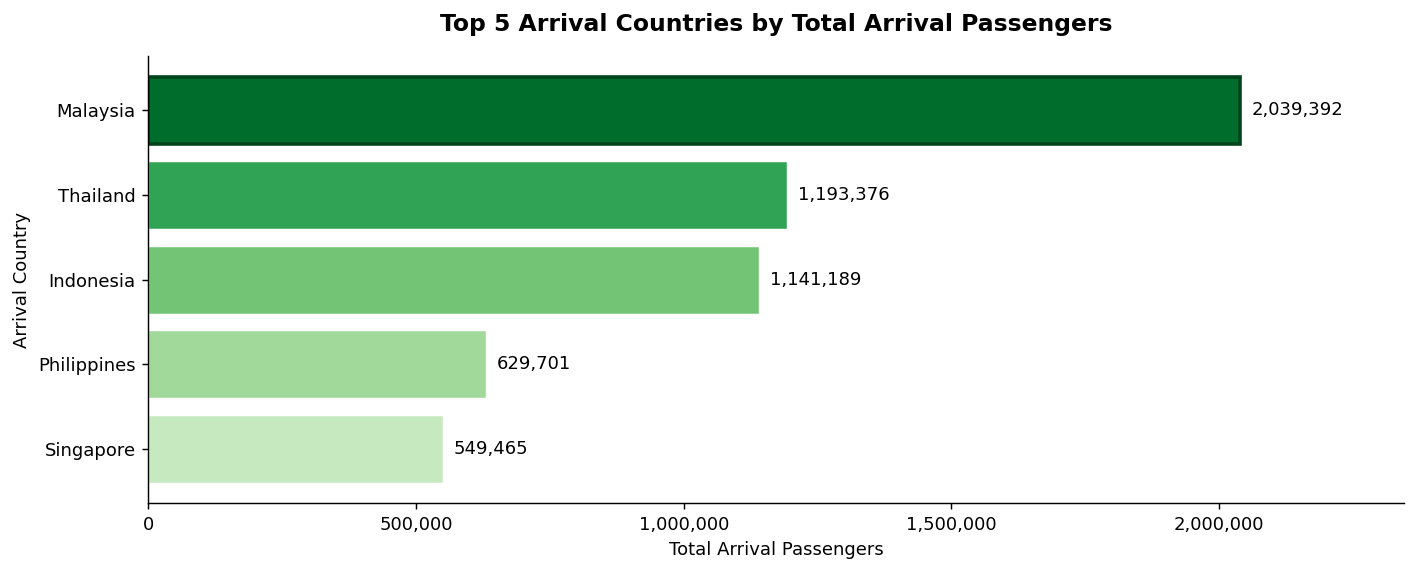

In [ ]:
# V2: use TotalArr
top5_arr_country = (
    df.groupby('ArrivalCountry')['TotalArr']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 4.5))

arr_colors = ['#c7e9c0', '#a1d99b', '#74c476', '#31a354', '#006d2c']
bars = ax.barh(top5_arr_country.index, top5_arr_country.values,
               color=arr_colors, edgecolor='white', linewidth=0.8)

bars[-1].set_edgecolor('#00441b')
bars[-1].set_linewidth(2)

for bar in bars:
    w = bar.get_width()
    ax.text(w + top5_arr_country.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{int(w):,}', va='center', fontsize=10)

ax.set_title('Top 5 Arrival Countries by Total Arrival Passengers',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Total Arrival Passengers')
ax.set_ylabel('Arrival Country')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, top5_arr_country.max() * 1.15)

plt.tight_layout()
plt.show()